In [1]:

import math
import statistics as stat
import textwrap

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import folium

from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight

import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import AUC
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Load dataset

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

"Total Charges" is type object but its type should be numeric.

In [4]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [5]:
col_w_null = [x for x in df.columns[df.isna().sum() > 0]]
df[col_w_null].isna().sum().rename("NULL count")

Total Charges      11
Churn Reason     5174
Name: NULL count, dtype: int64

"Total Charges" and "Churn Reason" have NULL values. I'll check this values 

In [6]:
df['Churn Reason'][df['Churn Reason'].isna()]

1869    NaN
1870    NaN
1871    NaN
1872    NaN
1873    NaN
       ... 
7038    NaN
7039    NaN
7040    NaN
7041    NaN
7042    NaN
Name: Churn Reason, Length: 5174, dtype: str

"Churn Reason" NULLs are  missing values. It makes sense because customers who have not churned would not have a churn reason

In [7]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

The number of missing values in "Churn Reason" corresponds to the number of 'No' in "Churn Label" and '0' in "Churn Value"

In [9]:
print(all(df[df["Churn Reason"].isna()]["CustomerID"] == df[df["Churn Value"] == 0]["CustomerID"]))

True


All missing values in 'Churn Reason' correspond to Customers who have not churned

In [10]:
df['Total Charges'][df['Total Charges'].isna()]

2234   NaN
2438   NaN
2568   NaN
2667   NaN
2856   NaN
4331   NaN
4687   NaN
5104   NaN
5719   NaN
6772   NaN
6840   NaN
Name: Total Charges, dtype: float64

"Total Charges" NULLs are missing values too

In [11]:
print(all(df[df["Total Charges"].isna()]["CustomerID"] == df[df["Tenure Months"] == 0]["CustomerID"]))

True


All the rows where "Total Charges" is missing have a 0 for the "Tenure Months", which means these customers have just joined and therefore have not paid their first rate yet. Hence, total charges can be set to 0.

In [12]:
df["Total Charges"] = np.where(df["Total Charges"].isna() == True, 0, df["Total Charges"])

In [13]:
df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

#### Investigate columns' cardinality

In [14]:
print(f'Lenght of PK: {len(df['CustomerID'])}')
print(f'Unique values of PK: {df['CustomerID'].nunique()}')

Lenght of PK: 7043
Unique values of PK: 7043


No duplicate customers are present

In [15]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

I'll remove columns having 1 value only

In [16]:
df.drop(columns=df.columns[df.nunique() == 1], inplace=True)

In [17]:
df.nunique()

CustomerID           7043
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [18]:
for col in df:
    print()
    print(f' {df[col].name} ( {df[col].nunique()} uniques )')
    print(df[col].unique())
    print()


 CustomerID ( 7043 uniques )
<StringArray>
['3668-QPYBK', '9237-HQITU', '9305-CDSKC', '7892-POOKP', '0280-XJGEX',
 '4190-MFLUW', '8779-QRDMV', '1066-JKSGK', '6467-CHFZW', '8665-UTDHZ',
 ...
 '0871-OPBXW', '3605-JISKB', '9767-FFLEM', '8456-QDAVC', '7750-EYXWZ',
 '2569-WGERO', '6840-RESVB', '2234-XADUH', '4801-JZAZL', '3186-AJIEK']
Length: 7043, dtype: str


 City ( 1129 uniques )
<StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str


 Zip Code ( 1652 uniques )
[90003 90005 90006 ... 96128 96134 96146]


 Lat Long ( 1652 uniques )
<StringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.048013, -118.293

### Descriptive Statistics

#### Univariate Analysis

In [19]:
def count_outliers(s):
    """Return number of outliers in a numeric Series using 1.5*IQR rule."""
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((s < lower) | (s > upper)).sum()

In [20]:
# Select numeric columns
num_df = df.select_dtypes(include=np.number)

# Compute numeric summaries
num_summary = num_df.agg(['count', 'mean', 'median', stat.mode, 'std', 'min', 'max', 'skew', 'kurt', count_outliers, ])

# Select categorical columns
cat_df = df.select_dtypes(exclude=np.number)

# Compute categorical summaries
cat_summary = pd.DataFrame({
    'unique': cat_df.nunique(),
    'top': cat_df.mode().iloc[0],
    'freq': cat_df.apply(lambda x: x.value_counts().iloc[0]),
    'missing': cat_df.isna().sum(),
})

cat_summary['%missing'] = 100 * cat_summary['missing'] / len(df)



In [21]:
num_summary

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
median,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
mode,90003.000000,33.964131,-121.994813,1.000000,20.050000,20.200000,0.000000,80.000000,5546.000000
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000
skew,-0.251463,0.303867,-0.040792,0.239540,-0.220524,0.963235,1.063031,-0.089840,-0.311602
kurt,-1.154043,-1.135607,-1.136050,-1.387372,-1.257260,-0.228580,-0.870211,-1.005679,-0.934032
count_outliers,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [22]:
cat_summary

,unique,top,freq,missing,%missing
CustomerID,7043,0002-ORFBO,1,0,0.000000
City,1129,Los Angeles,305,0,0.000000
Lat Long,1652,"32.555828, -117.040073",5,0,0.000000
Gender,2,Male,3555,0,0.000000
Senior Citizen,2,No,5901,0,0.000000
Partner,2,No,3641,0,0.000000
Dependents,2,No,5416,0,0.000000
Phone Service,2,Yes,6361,0,0.000000
Multiple Lines,3,No,3390,0,0.000000
Internet Service,3,Fiber optic,3096,0,0.000000


Text(0, 0.5, 'Count')

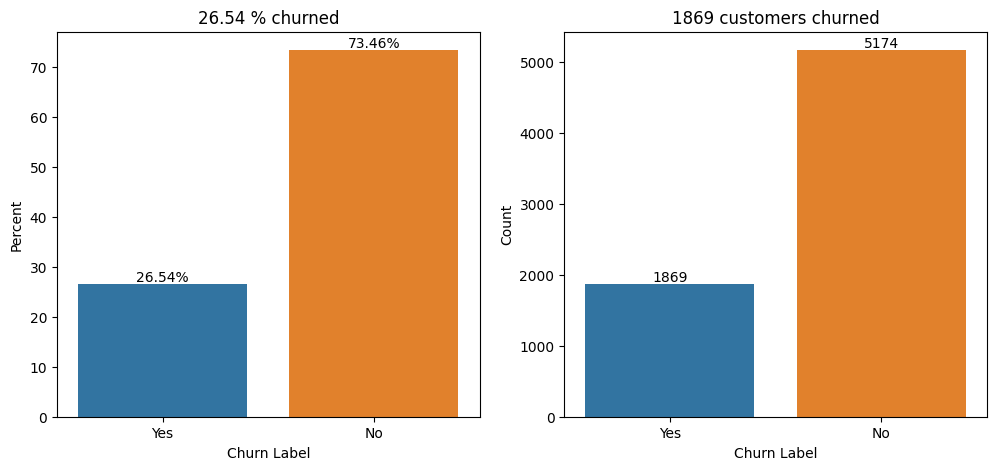

In [23]:
fig, axes = plt.subplots(1, 2, figsize= (12,5))

ax1 = sns.countplot(x='Churn Label', data=df, stat = 'percent', hue='Churn Label', ax= axes[0])
ax1.bar_label(ax1.containers[0], fmt='%.2f%%')
ax1.bar_label(ax1.containers[1], fmt='%.2f%%')
churn_rate = round(((df['Churn Label'] == 'Yes').sum() / len(df['CustomerID'])) * 100 , 2)
ax1.set_title(f'{churn_rate} % churned')
ax1.set_ylabel('Percent')

ax2 = sns.countplot(x='Churn Label', data=df, stat = 'count', hue='Churn Label', ax= axes[1])
ax2.bar_label(ax2.containers[0])
ax2.bar_label(ax2.containers[1])
churn_count = (df['Churn Label'] == 'Yes').sum()
ax2.set_title(f'{churn_count} customers churned')
ax2.set_ylabel('Count')



In [24]:
df.columns

Index(['CustomerID', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
       'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [25]:
EDA_catcols = cat_df.drop(columns=['City', 'CustomerID', 'Lat Long', 'Churn Reason', 'Churn Label' ]).columns

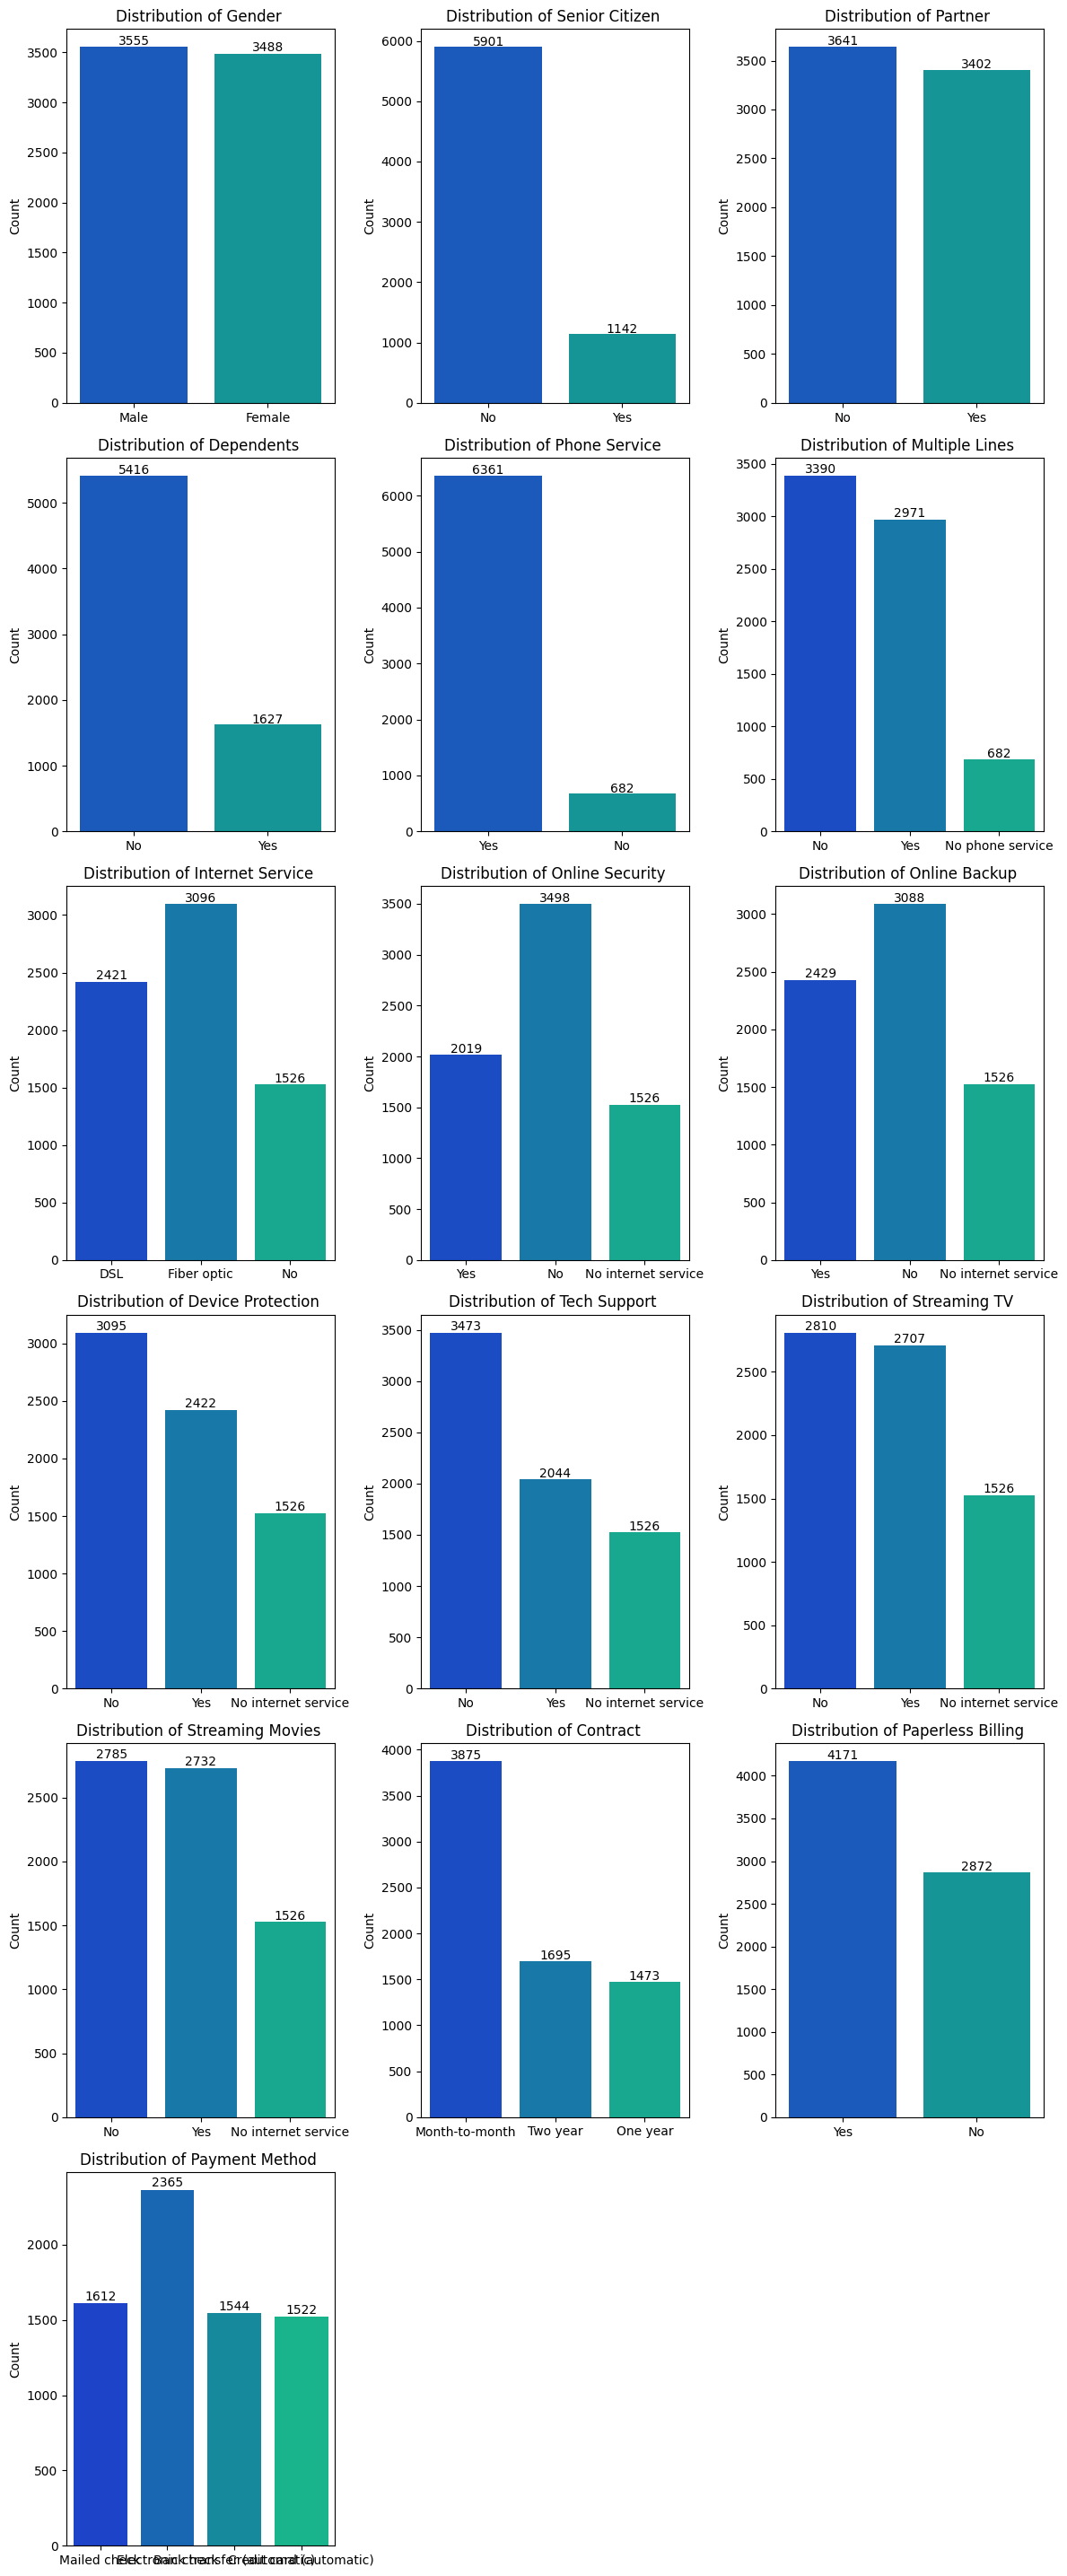

In [26]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(EDA_catcols)/3)),
    ncols=3,
    figsize=(12, len(EDA_catcols) * 1.8),
    tight_layout = True
    )

axes = axes.flatten()

for i, col in enumerate(EDA_catcols):
    ax1 = sns.countplot(x= col, data=df, stat = 'count', hue=col , palette='winter', ax= axes[i])
    for p in ax1.patches:
            height = p.get_height()
            ax1.text(p.get_x() + p.get_width()/2., height + 20, int(height), ha="center")
    ax1.set_title(f'Distribution of {col} ')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
        


In [27]:
EDA_numcols = num_df.drop(columns=['Zip Code', 'Churn Value']).columns

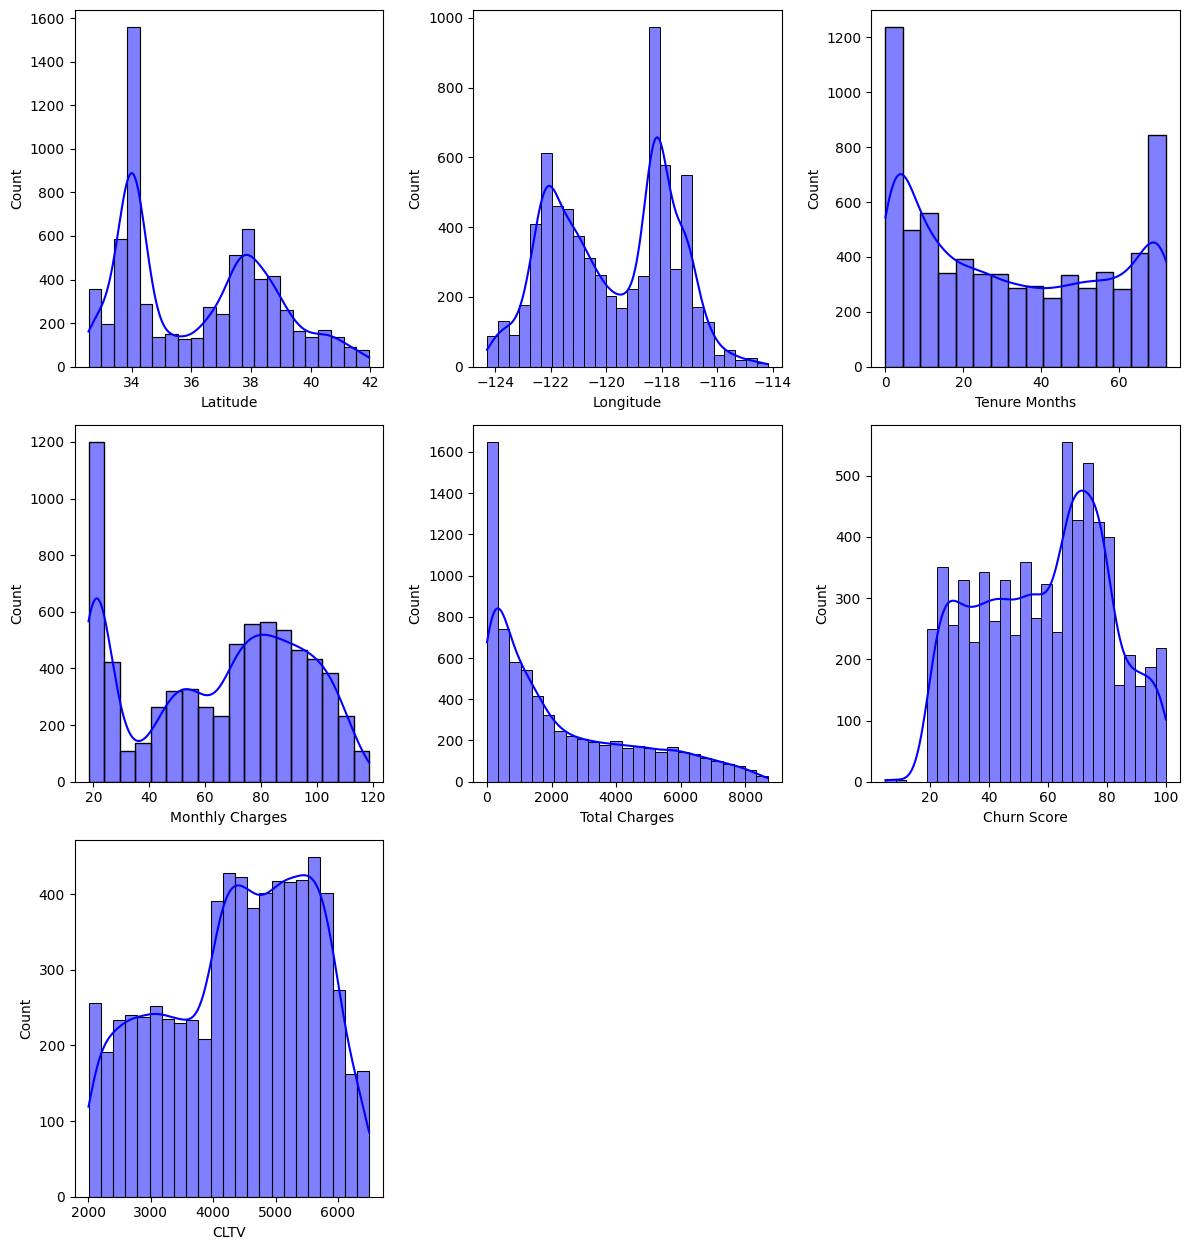

In [28]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(EDA_numcols) / 3)),
    ncols=3,
    figsize=(12, len(EDA_numcols) * 1.8),
    tight_layout=True
)

axes = axes.flatten()

for i, col in enumerate(EDA_numcols):
    sns.histplot(data=df, x=col, kde=True, bins='auto', color='blue', legend=False, ax=axes[i])
    plt.xlabel(col)
    plt.ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

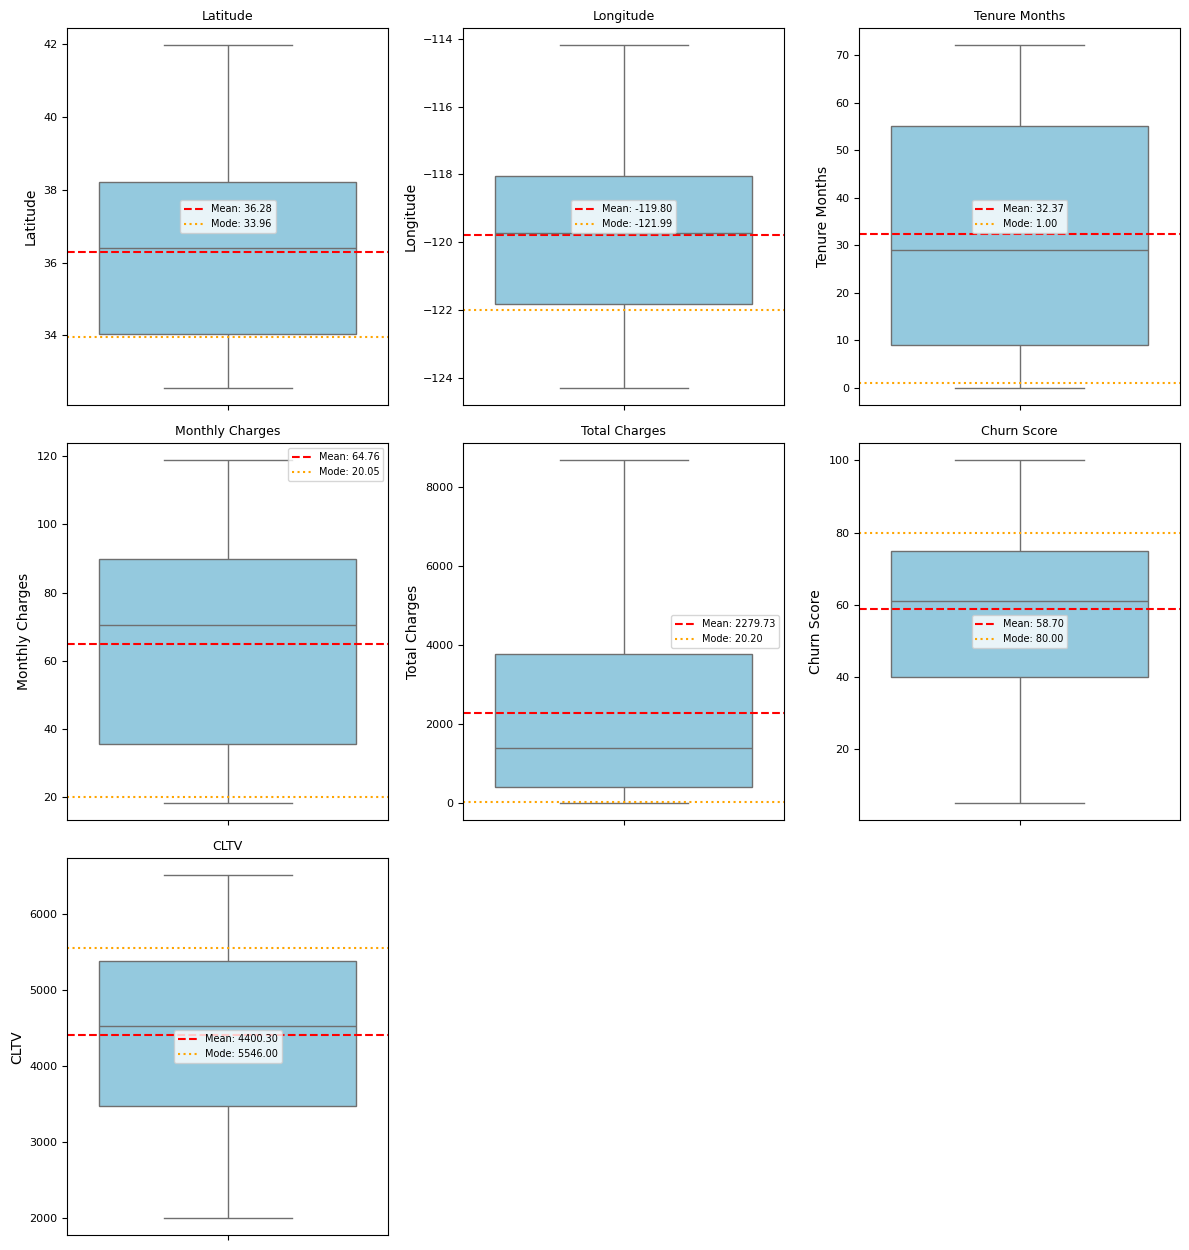

In [29]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(EDA_numcols) / 3)),
    ncols=3,
    figsize=(12, len(EDA_numcols) * 1.8),
    tight_layout=True
)

axes = axes.flatten()

for i, col in enumerate(EDA_numcols):
    sns.boxplot(df[col], ax=axes[i], fill=True, color='skyblue')
    axes[i].tick_params(axis='both', labelsize=8)
    # Add lines
    mean = stat.mean(df[col])
    median = stat.median(df[col])
    mode = stat.mode(df[col])
    axes[i].axhline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
    axes[i].axhline(mode, color='orange', linestyle=':', label=f'Mode: {mode:.2f}')

    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



#### location attributes engineering

I want to summarise location attributes and make them more meaningful and easier to analyse and feed to a model

In [30]:
# Cluster based on lat/long
coords = df[['Latitude', 'Longitude']].copy()
kmeans = KMeans(n_clusters=30, random_state=42)
df['zone'] = kmeans.fit_predict(coords)
print(len(df['zone'].unique()))
df['zone'].unique()



30


array([13,  1, 19, 17,  5, 21, 14, 23, 22,  8,  6,  3, 12, 28, 15,  0, 29,
        7, 25, 18,  9, 11, 20,  4, 16, 27,  2, 26, 10, 24], dtype=int32)

C:\Users\franc\AppData\Local\Temp\ipykernel_13380\899942039.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(df['Longitude'], df['Latitude'], c=df['zone'], s=10, cmap=plt.cm.get_cmap('tab20', 30))


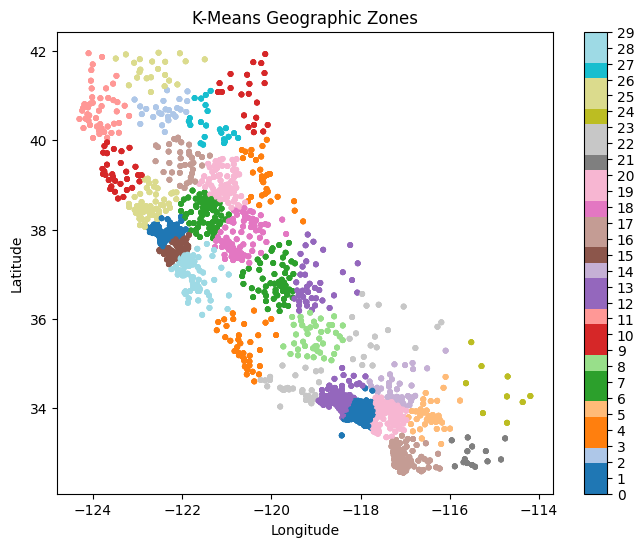

In [31]:
plt.figure(figsize=(8, 6))
# Combine tab20 + tab20b to get 40 colors
colors = np.vstack([plt.get_cmap('tab20').colors, plt.get_cmap('tab20b').colors])

# Use in scatter plot
plt.scatter(df['Longitude'], df['Latitude'], c=df['zone'], s=10, cmap=plt.cm.get_cmap('tab20', 30))
plt.colorbar(ticks=range(30))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Geographic Zones')
plt.show()

In [32]:
# Compute average distance between each point and its cluster center
distances = np.linalg.norm(coords - kmeans.cluster_centers_[df['zone']], axis=1)
print(f"Average within-cluster distance: {distances.mean():.4f}")

Average within-cluster distance: 0.3214


In [33]:
score = silhouette_score(coords, df['zone'])
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.375


In [34]:
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=6)

for _, row in df.sample(1000, random_state=42).iterrows():  # sample for performance
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color=f"#{hex(255 - row['zone'] * 5)[2:]}00{hex(row['zone'] * 5)[2:]}",
        fill=True
    ).add_to(m)

m

I'll substitute columns representing location with the 'Zone' column

In [35]:
df = df.drop(columns=['City', 'Zip Code', 'Latitude', 'Longitude', 'Lat Long'])

In [36]:
EDA_numcols = EDA_numcols.drop(['Latitude', 'Longitude'])
EDA_numcols

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score',
       'CLTV'],
      dtype='str')

#### Bivariate Analysis

In [37]:
pvalues_dict = {}

for col in EDA_catcols:
    ct = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, dof, expected = chi2_contingency(ct)
    pvalues_dict[col] = round(p, 4)

sorted_pvalues_dict = dict(sorted(pvalues_dict.items(), key=lambda x: x[1]))
sorted_pvalues_dict

{'Senior Citizen': np.float64(0.0),
 'Partner': np.float64(0.0),
 'Dependents': np.float64(0.0),
 'Internet Service': np.float64(0.0),
 'Online Security': np.float64(0.0),
 'Online Backup': np.float64(0.0),
 'Device Protection': np.float64(0.0),
 'Tech Support': np.float64(0.0),
 'Streaming TV': np.float64(0.0),
 'Streaming Movies': np.float64(0.0),
 'Contract': np.float64(0.0),
 'Paperless Billing': np.float64(0.0),
 'Payment Method': np.float64(0.0),
 'Multiple Lines': np.float64(0.0035),
 'Phone Service': np.float64(0.3388),
 'Gender': np.float64(0.4866)}

p-value is higher than 0.05 for 'zone', 'Phone Service' and 'Gender'. There isn't a statistically significant association between these attributes and the target. It is safe to drop these attributes.

Visual confirmation

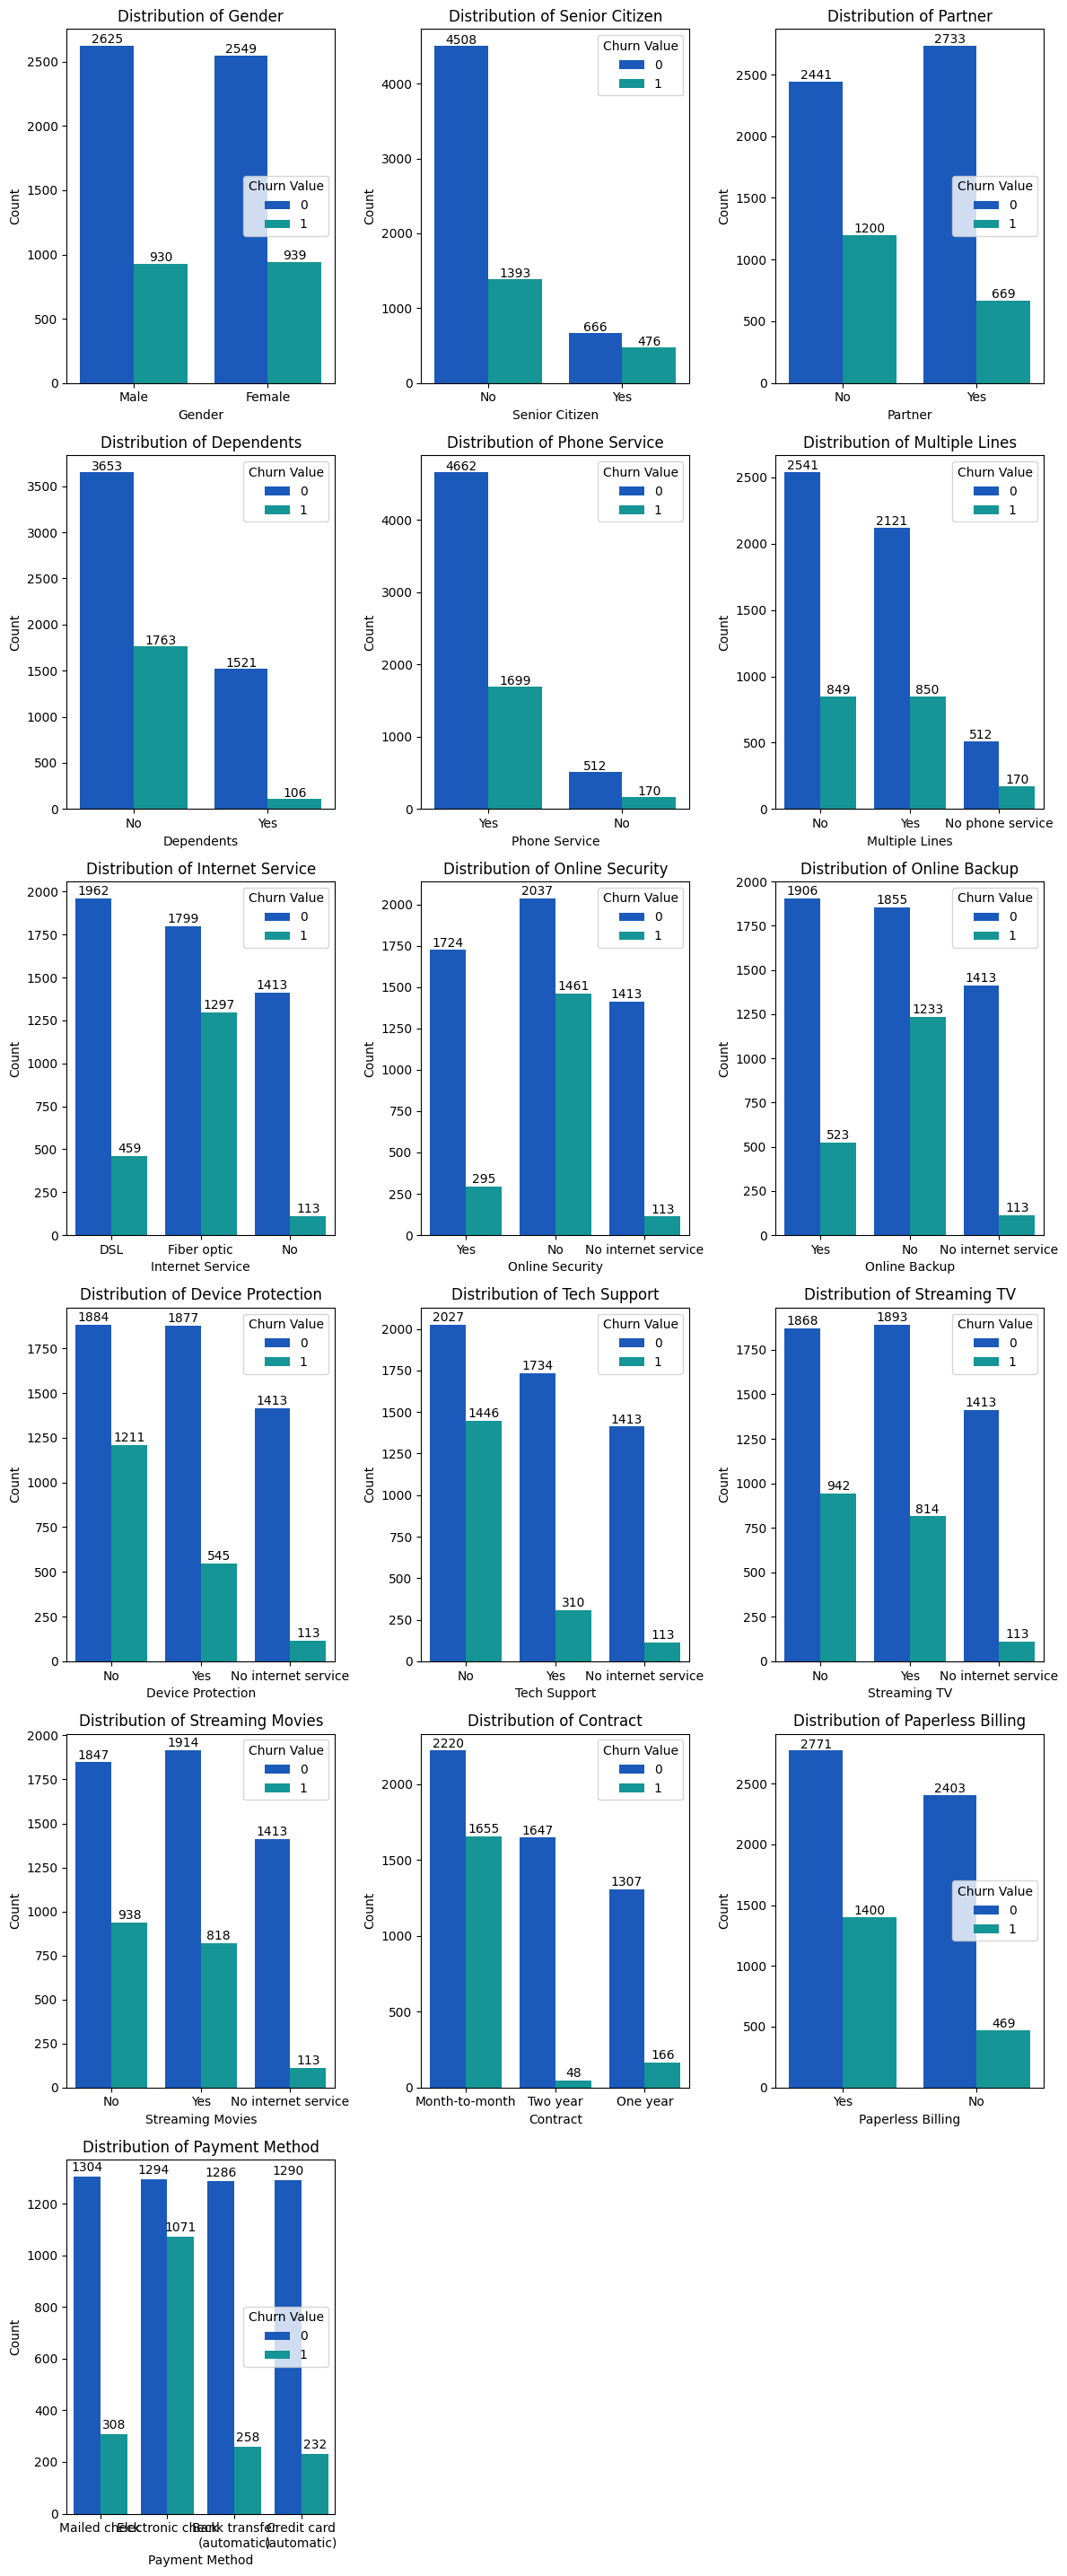

In [38]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(EDA_catcols)/3)),
    ncols=3,
    figsize=(12, len(EDA_catcols) * 1.8),
    tight_layout = True
    )

axes = axes.flatten()

for i, col in enumerate(EDA_catcols):
    ax = sns.countplot(data=df, x=col, hue="Churn Value", palette='winter', ax= axes[i])

        # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2., height + 20, int(height), ha="center")

    labels = [textwrap.fill(label, 20) for label in df[col].unique()]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels)
        
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

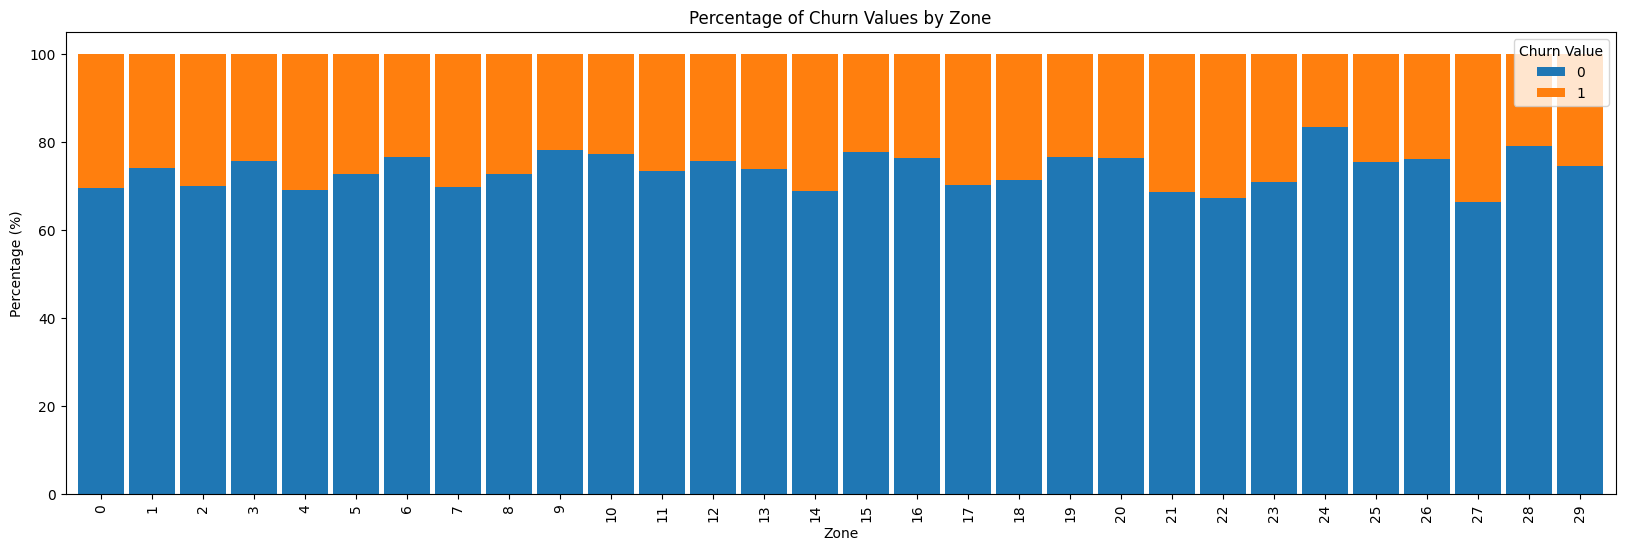

In [39]:
# Count churn values per zone
zone_churn_counts = df.groupby(['zone', 'Churn Value']).size().reset_index(name='Count')

# Compute percentages
zone_totals = zone_churn_counts.groupby('zone')['Count'].transform('sum')
zone_churn_counts['Percentage'] = 100 * zone_churn_counts['Count'] / zone_totals

# Pivot for plotting
pivot_pct = zone_churn_counts.pivot(index='zone', columns='Churn Value', values='Percentage')

# Sort cities by sample size (optional but helps)
# pivot_pct = pivot_pct.loc[valid_zones]

# Plot
pivot_pct.plot(kind='bar', stacked=True, figsize=(20,6), width=0.9)
plt.title('Percentage of Churn Values by Zone')
plt.ylabel('Percentage (%)')
plt.xlabel('Zone')
plt.xticks(rotation=90)
plt.legend(title='Churn Value')

In [40]:
col_todrop = ['zone', 'Phone Service', 'Gender']

In [41]:
corr = df[pd.Index(list(EDA_numcols) + ['Churn Value'])].corr()

In [42]:
corr_dict = {}

for col in EDA_numcols:
    corr_dict[col] = round(corr[col]['Churn Value'], 4)

sorted_corr_dict = dict(sorted(corr_dict.items(), key=lambda x: abs(x[1]), reverse=True))
sorted_corr_dict

{'Churn Score': np.float64(0.6649),
 'Tenure Months': np.float64(-0.3522),
 'Total Charges': np.float64(-0.1983),
 'Monthly Charges': np.float64(0.1934),
 'CLTV': np.float64(-0.1275)}

<Axes: >

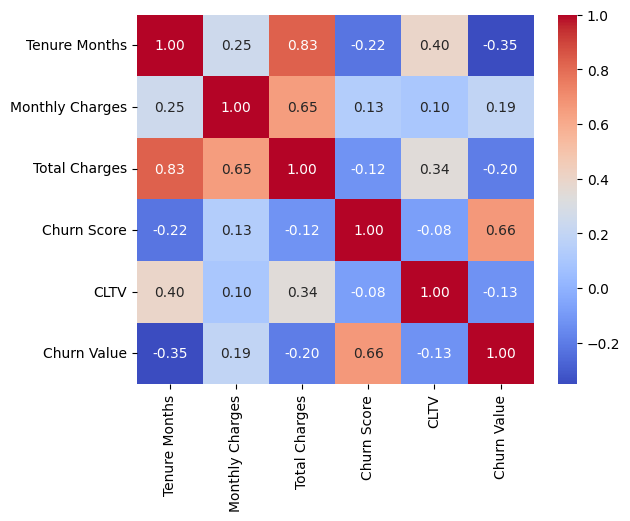

In [43]:

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [44]:
col_todrop

['zone', 'Phone Service', 'Gender']

In [45]:
col_todrop.append('CustomerID')
col_todrop.append('Churn Reason')

In [46]:
col_todrop.append('Churn Label')
col_todrop.append('Churn Score')

In [47]:
col_todrop

['zone',
 'Phone Service',
 'Gender',
 'CustomerID',
 'Churn Reason',
 'Churn Label',
 'Churn Score']

### Preprocessing

In [48]:
df1 = df.drop(columns=col_todrop)

In [49]:
df1.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV'],
      dtype='str')

#### Split

In [50]:
X = df1.drop(columns=['Churn Value'])
y = df1['Churn Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### One-Hot Encoding

In [51]:
cat_cols = df1.select_dtypes(include='object').columns

C:\Users\franc\AppData\Local\Temp\ipykernel_13380\3802124880.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df1.select_dtypes(include='object').columns


In [52]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [53]:
X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

#### Scaling

In [54]:
robust_cols = ["Total Charges"]
standard_cols = ["Tenure Months", "Monthly Charges", "CLTV"]

scaler_robust = RobustScaler()
scaler_std = StandardScaler()

X_train_robust = scaler_robust.fit_transform(X_train[robust_cols])
X_test_robust = scaler_robust.transform(X_test[robust_cols])

X_train_std = scaler_std.fit_transform(X_train[standard_cols])
X_test_std = scaler_std.transform(X_test[standard_cols])

In [55]:
X_train_final = np.hstack([X_train_robust, X_train_std, X_train_encoded])
X_test_final  = np.hstack([X_test_robust, X_test_std,  X_test_encoded])

In [56]:
X_train_final = np.array(X_train_final)
X_test_final  = np.array(X_test_final)
y_train = np.array(y_train)
y_test  = np.array(y_test)

### Training

In [158]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

model = keras.Sequential([
    keras.Input(shape=(43,)),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', AUC(curve='PR', name='pr_auc')]
)

early_stop = EarlyStopping(
    monitor='val_pr_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)
reduce_lr = ReduceLROnPlateau(monitor='val_Recall', factor=0.5, patience=10, min_lr=1e-6)

history = model.fit(
    X_train_final, y_train,
    epochs=35,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    shuffle=True,
    class_weight=dict(enumerate(class_weights))
)

Epoch 1/35
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - Precision: 0.3453 - Recall: 0.7225 - accuracy: 0.5613 - loss: 0.7323 - pr_auc: 0.3608 - val_Precision: 0.4129 - val_Recall: 0.8915 - val_accuracy: 0.6398 - val_loss: 0.6069 - val_pr_auc: 0.5134 - learning_rate: 0.0010
Epoch 2/35
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Precision: 0.4071 - Recall: 0.8325 - accuracy: 0.6326 - loss: 0.6019 - pr_auc: 0.4844 - val_Precision: 0.4180 - val_Recall: 0.8983 - val_accuracy: 0.6460 - val_loss: 0.5940 - val_pr_auc: 0.5432 - learning_rate: 0.0010
Epoch 3/35
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.4382 - Recall: 0.8308 - accuracy: 0.6714 - loss: 0.5591 - pr_auc: 0.5274 - val_Precision: 0.4397 - val_Recall: 0.8644 - val_accuracy: 0.6761 - val_loss: 0.5647 - val_pr_auc: 0.5611 - learning_rate: 0.0010
Epoch 4/35
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.4552 - Recall: 0.8217 - accuracy: 0.6907 - loss: 0.5435 - pr_auc: 0.5459 - val_Precision: 0.4450 - val_Recall: 0.8780 - val_

### Evaluation

In [159]:
y_pred_proba = model.predict(X_test_final)
y_pred = (y_pred_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.94      0.63      0.75      1035
           1       0.46      0.88      0.60       374

    accuracy                           0.69      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.69      0.71      1409



In [160]:
model.evaluate(X_test_final, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.4983 - Recall: 0.8021 - accuracy: 0.7331 - loss: 0.4968 - pr_auc: 0.6393


[0.49680355191230774,
 0.7331440448760986,
 0.49833887815475464,
 0.8021390438079834,
 0.639264702796936]

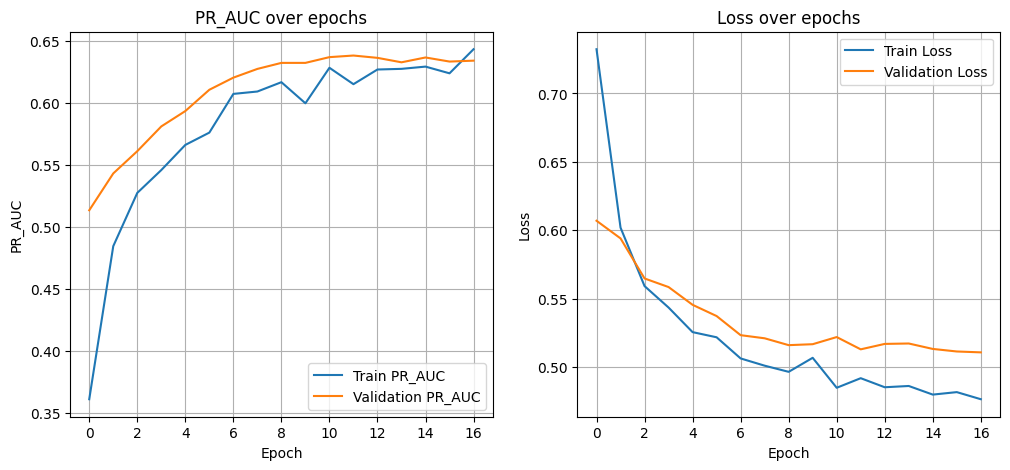

In [161]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['pr_auc'], label='Train PR_AUC')
plt.plot(history.history['val_pr_auc'], label='Validation PR_AUC')
plt.title('PR_AUC over epochs')
plt.xlabel('Epoch')
plt.ylabel('PR_AUC')
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

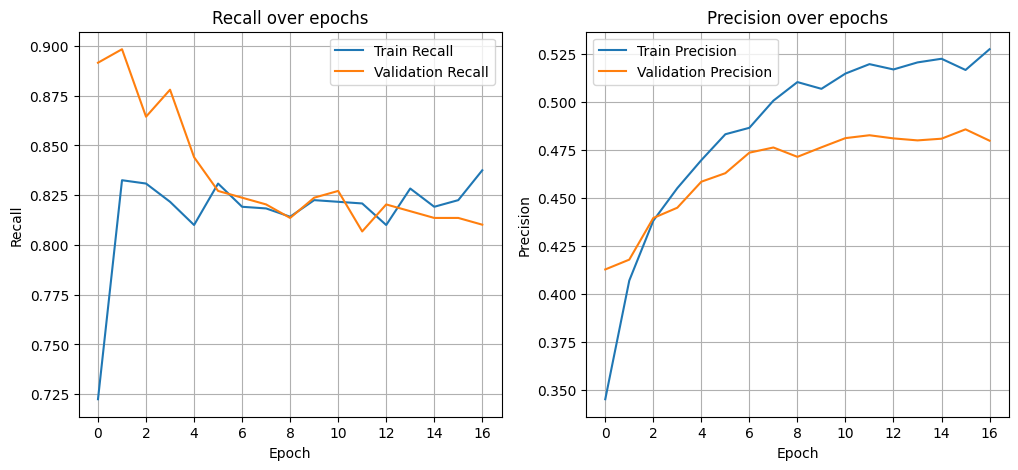

In [162]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['Recall'], label='Train Recall')
plt.plot(history.history['val_Recall'], label='Validation Recall')
plt.title('Recall over epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['Precision'], label='Train Precision')
plt.plot(history.history['val_Precision'], label='Validation Precision')
plt.title('Precision over epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.show()

Despite slight overfitting, the model has a good recall. Around 0.49 Precision might affect the retation campaign budget if intervention costs are not as low.
However, around 80 % of churners will be identified in advance, potentially preventing significant amount of money loss.     